# LangGraph 기초

### 필요한 패키지 설치
`pip install langgraph`

In [2]:
import operator
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_chroma import Chroma
from langchain_core.messages import AIMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

load_dotenv()

True

### 직선형 Chain을 넘어서는 요구사항

LCEL Chain은 입력을 정해진 순서로 처리하는 **직선형 파이프라인**에 잘 맞는다.

```
입력 → 프롬프트 → 모델 → 출력 파서 → 결과
```

하지만 실제 서비스에는 실행 도중 다음 행동을 결정해야 하는 상황이 자주 등장한다.

- 고객 문의를 처리할 때 환불 요청은 환불 담당 흐름으로, 제품 문의는 상담 흐름으로 보내야 한다.
- 문서를 검색했는데 답변에 필요한 내용이 부족하면 질문을 고쳐 다시 검색해야 한다. 검색이 계속 실패하면 정해진 횟수에서 중단해야 한다.
- 결제나 메일 발송처럼 영향이 큰 작업은 실행 직전에 멈추고 사용자의 승인을 기다려야 한다.
- 실행 중 오류가 발생하면 처음부터 다시 시작하지 않고 저장된 상태를 바탕으로 이어서 처리해야 한다.
- Agent가 검색, 계산, 데이터 조회 중 어떤 Tool이 필요한지 판단하고 결과가 충분할 때까지 사용해야 한다.

이 요구사항들도 일반 Python 코드와 LangChain을 조합하면 구현할 수 있다. 문제는 분기, 반복, 상태 저장, 중단과 재개가 늘어날수록 **제어 로직이 Chain 밖의 조건문과 반복문으로 흩어진다**는 점이다. 실행 흐름을 이해하고 추적하거나, 중간 상태에서 다시 시작하는 일도 점점 어려워진다.

| 필요한 제어 흐름 | 자연어 사례 | LangGraph에서 사용할 개념 |
|---|---|---|
| 조건 분기 | 문의 유형에 따라 서로 다른 처리 과정 선택 | 조건부 Edge |
| 반복과 종료 조건 | 검색 결과가 부족하면 질문을 바꾸어 재검색 | 순환 구조, 조건부 Edge |
| 중간 결과 누적 | 조사 결과와 남은 작업을 단계마다 공유 | State, Reducer |
| 사람의 개입 | 승인받을 때까지 실행을 멈추고 이후 재개 | Interrupt, Checkpoint |
| 병렬 처리와 취합 | 여러 분석을 동시에 수행한 뒤 결과 통합 | Send, Reducer |
| 장애 후 복구 | 저장된 중간 상태부터 작업 재개 | Checkpoint |
| 동적인 행동 선택 | LLM이 다음 Tool과 실행 횟수를 결정 | Agent, ToolNode |

> LangGraph는 LangChain으로 할 수 없던 일을 가능하게 만드는 도구라기보다, 복잡한 제어 흐름과 상태 변화를 **명시적인 그래프**로 관리하게 해주는 프레임워크다.

### 대표 사례: 검색 결과가 부족하면 재검색

앞의 여러 상황을 모두 코드로 구현하지 않고, 그중 반복과 종료 조건이 필요한 사례 하나만 살펴보자.

"검색 결과가 부족하면 질문을 바꾸어 다시 검색한다"는 요구사항을 일반 Python 코드와 Chain으로 구현하면 다음과 같이 제어 로직이 Chain 밖으로 나오게 된다.

In [3]:
EMBEDDING_MODEL_NAME = "gemini-embedding-2"
MODEL_NAME = "gemini-3.6-flash"

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

vectorstore = Chroma(
    embedding_function=embeddings,
    collection_name="spri_ai_brief",
    persist_directory="./chroma_db",
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [5]:
question = "AI 반도체 시장의 전망은?"
max_retries = 3

for attempt in range(max_retries):
    docs = retriever.invoke(question)
    context = format_docs(docs)

    check = llm.invoke([
        HumanMessage(
            content=f"질문: {question}\n\n검색 결과:\n{context}\n\n"
            "이 검색 결과가 질문에 답변하기에 충분한가? 'yes' 또는 'no'로만 답해."
        )
    ])

    print(f"[시도 {attempt + 1}] 질문: {question}")
    check_text = check.text
    print(f"  충분한가? {check_text}")

    if "yes" in check_text.lower():
        break

    rewrite = llm.invoke([
        HumanMessage(
            content=f"'{question}'이라는 질문으로 문서를 검색했지만 충분한 결과가 없었다. "
            "같은 의도이지만 다른 표현으로 질문을 다시 작성해줘. 질문만 출력해."
        )
    ])
    question = rewrite.text

print(f"\n→ 모델 호출은 Chain 안에 있지만, 반복과 종료 조건은 Python 루프가 제어한다.")
print("→ 요구사항이 늘어날수록 제어 흐름과 상태 관리가 Chain 밖으로 흩어진다.")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[시도 1] 질문: AI 반도체 시장의 전망은?
  충분한가? no
[시도 2] 질문: 1. 인공지능(AI) 반도체 산업의 향후 성장 가능성과 트렌드는 어떤가요?
2. AI 칩 시장 규모 예측 및 차세대 반도체 동향은 무엇인가요?
3. 앞으로의 AI 반도체 시장 발전 방향과 글로벌 산업 전망을 알려주세요.
  충분한가? no
[시도 3] 질문: 1. AI 가속기 및 NPU 산업의 미래 성장 동력과 주요 기술 트렌드는 무엇인가요?
2. 글로벌 AI 칩 시장 규모 전망과 HBM, PIM 등 차세대 반도체 개발 동향은 어떠한가요?
3. 빅테크 기업의 AI 반도체 자체 개발 현황과 향후 글로벌 생태계의 발전 방향은 무엇인가요?
  충분한가? no

→ 모델 호출은 Chain 안에 있지만, 반복과 종료 조건은 Python 루프가 제어한다.
→ 요구사항이 늘어날수록 제어 흐름과 상태 관리가 Chain 밖으로 흩어진다.


## Workflow vs Agent

AI 애플리케이션의 제어 방식은 **스펙트럼** 위에 있다.

```
개발자가 흐름 결정                                    LLM이 흐름 결정
├──────────────────────────────────────────────────────────┤
Chain       Workflow        Agent           Autonomous Agent
(직선)       (분기+루프)     (LLM이 판단)            (완전 자율)
```

| 방식 | 제어 주체 | 예시 |
|------|----------|------|
| **Chain** | 개발자가 모든 흐름을 고정 | 번역 → 요약 → 출력 |
| **Workflow** | 개발자가 분기/루프 설계 | 검색 결과 부족하면 재검색 |
| **Agent** | LLM이 다음 행동을 결정 | 어떤 Tool을 몇 번 쓸지 LLM이 판단 |

Chain은 스펙트럼의 가장 왼쪽이다. **LangGraph는 이 스펙트럼 전체를 구현할 수 있는 프레임워크**다.

## LangGraph 핵심 개념

LangGraph는 3가지 개념으로 구성된다.

| 개념 | 역할 | 비유 |
|------|------|------|
| **State** | 전체 흐름에서 공유하는 데이터 | 칠판 — 모든 노드가 읽고 쓸 수 있음 |
| **Node** | 각 처리 단계 (Python 함수) | 작업자 — State를 받아서 처리하고 결과를 돌려줌 |
| **Edge** | 노드 간의 연결 | 화살표 — 다음에 어떤 노드로 갈지 결정 |


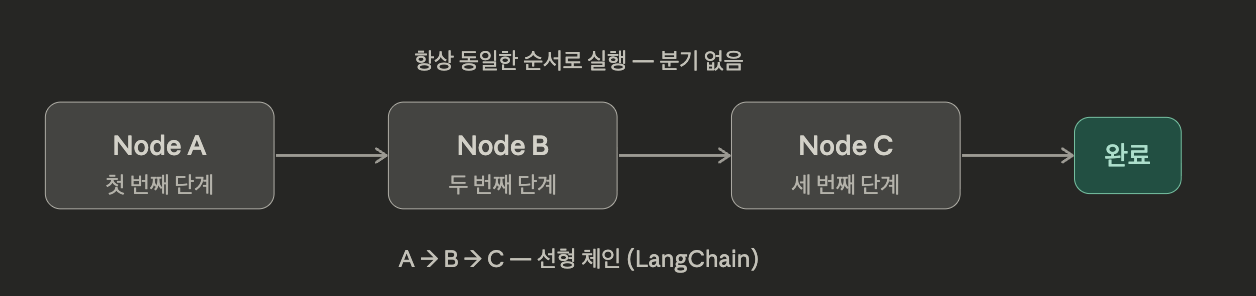

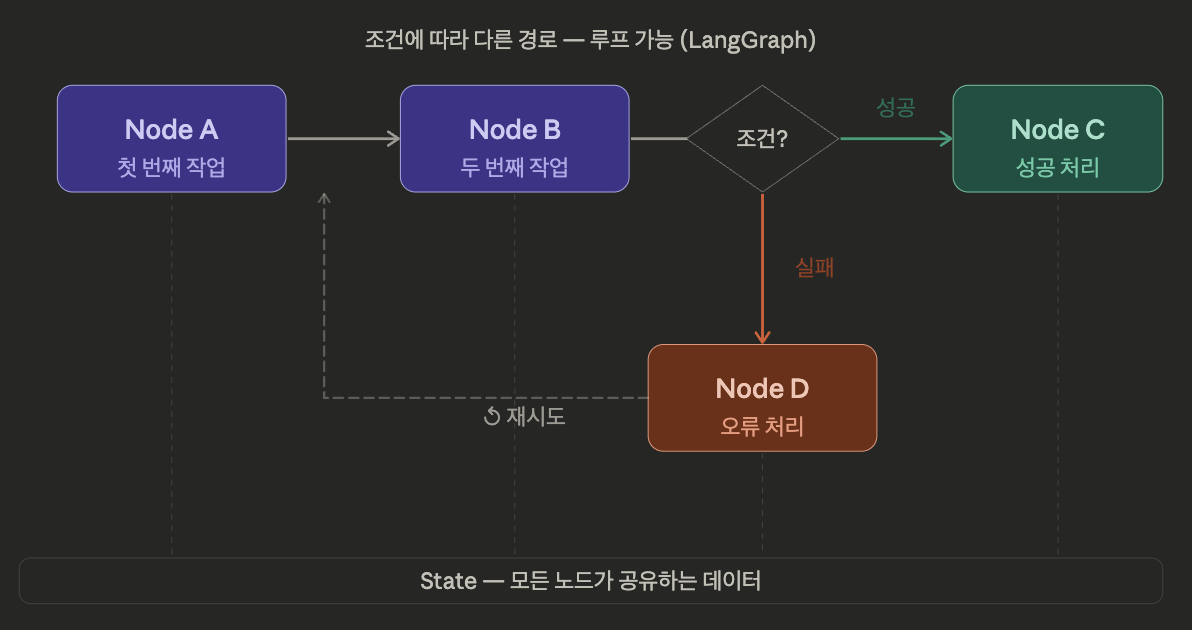

## 기본 그래프

LLM 하나를 노드로 사용하는 가장 기본적인 그래프를 만들어보자.

`START`와 `END`는 그래프의 시작과 종료 지점을 나타내는 특수 노드이다.

```
START → chatbot → END
```

### State 정의

State는 그래프 전체에서 공유하는 데이터 구조다. `TypedDict`로 정의한다.

`TypedDict`는 Python 표준 라이브러리(`typing`)에 포함된 타입으로, **딕셔너리의 키와 값 타입을 명시**할 수 있다.

```python
# 일반 dict — 어떤 키가 있는지, 값이 무슨 타입인지 알 수 없음
state = {"name": "홍길동", "age": 30}

# TypedDict — 키 이름과 타입이 명확
class State(TypedDict):
    name: str
    age: int
```

런타임에는 일반 `dict`와 동일하게 동작하지만, IDE 자동완성과 타입 검사를 지원한다.

In [7]:
class State(TypedDict):
    question: str
    answer: str

### Node 정의

노드는 **Python 함수**다. State를 받아서 업데이트할 내용을 반환한다.

In [9]:
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)


def chatbot(state: State):
    response = llm.invoke(state["question"])
    return {"answer": response.text}


노드 함수의 패턴은 항상 동일하다.

1. `state`를 인자로 받는다
2. state에서 필요한 데이터를 꺼내 처리한다
3. 업데이트할 필드를 dict로 반환한다

반환된 dict는 State에 **병합**된다.

### Graph 구성 + Edge 연결

In [10]:
# 그래프 생성
graph_builder = StateGraph(State)

# 노드 추가 (이름, 함수)
graph_builder.add_node("chatbot", chatbot)

# 엣지 추가
graph_builder.add_edge(START, "chatbot")  # 시작 → chatbot
graph_builder.add_edge("chatbot", END)    # chatbot → 종료

# 컴파일
graph = graph_builder.compile()

순서를 정리하면:

1. `StateGraph(State)` — State 스키마로 그래프 생성
2. `add_node(이름, 함수)` — 노드 등록
3. `add_edge(출발, 도착)` — 노드 간 연결
4. `compile()` — 실행 가능한 그래프로 변환

### 시각화

LangGraph는 그래프 구조를 이미지로 시각화할 수 있다.

`IPython.display`는 Jupyter 노트북 전용 모듈이다. 일반 Python 스크립트에서는 파일로 저장해야 한다.

```python
# .py 파일에서 사용할 경우
png_data = graph.get_graph().draw_mermaid_png()
with open("graph.png", "wb") as f:
    f.write(png_data)
```

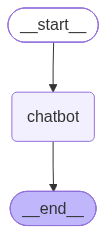

In [9]:
display(Image(graph.get_graph().draw_mermaid_png()))

### 실행

`graph.invoke(초기 State)`는 그래프를 실행하고 모든 노드의 처리가 끝난 뒤 최종 State를 반환한다.

In [10]:
result = graph.invoke({"question": "LangGraph가 뭐야?"})
print(result["answer"])

**LangGraph(랭그래프)**는 LangChain 팀에서 만든 **복잡하고 상태가 유지되는(Stateful) 멀티 에이전트 AI 애플리케이션을 구축하기 위한 프레임워크**입니다.

쉽게 말해, **"AI 에이전트가 스스로 생각하고, 행동하고, 실패하면 다시 시도하는 복잡한 작업 흐름을 '그래프(Graph)' 구조로 쉽게 만들 수 있게 해주는 도구"**입니다.

---

### 1. 왜 LangGraph가 등장했을까요? (LangChain과의 차이)

기존의 **LangChain**은 주로 프롬프트, LLM, 데이터베이스 등을 일직선으로 연결하는 **순차적인 작업(DAG: Directed Acyclic Graph)**에 최적화되어 있었습니다.
> *예: 질문 입력 ➔ 검색 ➔ 답변 생성 (끝)*

하지만 실제 복잡한 AI 에이전트를 만들 때는 **순환(Loop, 반복)** 구조가 필요합니다.
> *예: 질문 입력 ➔ 답변 작성 ➔ 검토 ➔ **(수정 필요시) 다시 작성** ➔ 완벽하면 종료*

기존 LangChain만으로는 이런 "피드백 루프"나 복잡한 상태 관리를 구현하기가 어려웠기 때문에, 이를 전담하기 위해 나온 것이 **LangGraph**입니다.

---

### 2. LangGraph의 핵심 개념

LangGraph는 수학의 '그래프 이론'처럼 **Node(노드)**, **Edge(엣지)**, **State(상태)** 3가지로 구성됩니다.

1. **State (상태):**
   * 그래프 전체에서 공유되는 **데이터(메모리)**입니다. AI의 대화 기록, 작업 진행 상황, 중간 결과물 등이 여기에 저장됩니다.
2. **Nodes (노드):**
   * 실제로 **작업을 수행하는 파이썬 함수**입니다. (예: LLM에게 질문하기, 웹 검색하기, 코딩하기 등)
   * 노드는 'State'를 받아서 작업을 수행한 뒤, 업데이트된 'State'를 반환합니다.
3. **Edges (엣지):**
   * **다음 단계로 어디로 이동할지 결정하는 조건문*

## 그래프: 조건부 분기

LangGraph의 조건부 엣지를 사용해 **조건 분기**를 구현해보자.

시나리오: 사용자 입력의 언어를 감지해서 한국어면 한국어로, 영어면 영어로 답변하는 그래프. 입력 언어는 한국어 또는 영어라고 가정한다.

```
START → detect_language → 한국어? → answer_ko → END
                          영어?  → answer_en → END
```

In [11]:
class RouterState(TypedDict):
    question: str
    language: str
    answer: str

In [12]:
def detect_language(state: RouterState):
    question = state["question"]
    result = llm.invoke(f"다음 문장의 언어가 한국어면 'ko', 영어면 'en'으로만 답해: {question}")
    return {"language": result.text.strip().lower()}


def answer_ko(state: RouterState):
    result = llm.invoke(f"한국어로 답변해줘: {state['question']}")
    return {"answer": result.text}


def answer_en(state: RouterState):
    result = llm.invoke(f"Answer in English: {state['question']}")
    return {"answer": result.text}

`add_edge`는 다음 노드가 고정되어 있지만, `add_conditional_edges`는 **함수의 반환값에 따라 다음 노드가 결정**된다.

```python
# 고정 연결
add_edge("A", "B")  # A 다음은 항상 B

# 조건부 연결
add_conditional_edges(
    "A",              # 출발 노드
    routing_function,  # State를 받아 문자열을 반환하는 함수
    {                  # 반환값 → 도착 노드 매핑
        "go_b": "B",
        "go_c": "C",
    },
)
```

In [13]:
def route_by_language(state: RouterState):
    """language에 따라 다음 노드를 결정하는 라우팅 함수"""
    if "ko" in state["language"]:
        return "ko"
    else:
        return "en"


graph_builder = StateGraph(RouterState)

graph_builder.add_node("detect_language", detect_language)
graph_builder.add_node("answer_ko", answer_ko)
graph_builder.add_node("answer_en", answer_en)

graph_builder.add_edge(START, "detect_language")
graph_builder.add_conditional_edges(
    "detect_language",    # 출발 노드
    route_by_language,    # 라우팅 함수
    {                     # 반환값 → 도착 노드 매핑
        "ko": "answer_ko",
        "en": "answer_en",
    },
)
graph_builder.add_edge("answer_ko", END)
graph_builder.add_edge("answer_en", END)

router_graph = graph_builder.compile()

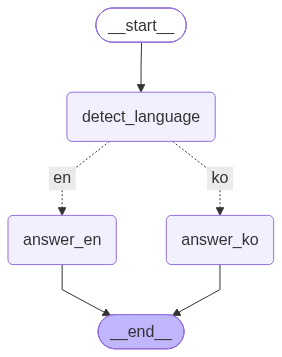

In [14]:
display(Image(router_graph.get_graph().draw_mermaid_png()))

In [15]:
# 한국어 입력
result = router_graph.invoke({"question": "파이썬의 장점이 뭐야?"})
print(f"언어: {result['language']}")
print(f"답변: {result['answer'][:200]}")
print()

# 영어 입력
result = router_graph.invoke({"question": "What are the benefits of Python?"})
print(f"언어: {result['language']}")
print(f"답변: {result['answer'][:200]}")

언어: ko
답변: 파이썬(Python)은 현재 전 세계에서 가장 인기 있는 프로그래밍 언어 중 하나입니다. 파이썬이 이토록 사랑받는 주요 장점들은 다음과 같습니다.

---

### 1. 배우기 쉽고 가독성이 뛰어남 (Easy to Learn & Read)
* **직관적인 문법:** 파이썬의 문법은 사람의 언어(영어)와 매우 유사합니다.
* **짧은 코드:** 다른 언어(C

언어: en
답변: Python is one of the most popular and widely used programming languages in the world today. Its popularity stems from a wide range of benefits that cater to both beginners and experienced developers. 


`invoke`가 그래프 실행이 끝난 뒤 최종 상태를 반환한다면, `graph.stream()`은 각 노드가 실행된 뒤의 상태 업데이트를 순서대로 반환한다. 이를 통해 조건에 따라 어떤 노드가 실행되었는지 확인할 수 있다.

`llm.stream()`이 모델의 응답을 토큰 또는 콘텐츠 조각 단위로 전달하는 것과 달리, `graph.stream()`은 기본적으로 상태 업데이트를 노드 단위로 반환한다.

In [16]:
for event in router_graph.stream({"question": "파이썬의 장점이 뭐야?"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

[detect_language] {'language': 'ko'}

[answer_ko] {'answer': '파이썬(Python)은 현재 전 세계에서 가장 인기 있는 프로그래밍 언어 중 하나입니다. 파이썬이 이토록 사랑받는 주요 장점들은 다음과 같습니다.\n\n---\n\n### 1. 배우기 쉽고 가독성이 뛰어남 (쉬운 문법)\n* **문법이 직관적입니다:** 파이썬은 사람이 사용하는 언어(영어)와 매우 유사하게 작성됩니다.\n* **코드가 간결합니다:** 다른 언어(C, Java 등)에 비해 훨씬 적은 줄 수의 코드로 같은 기능을 구현할 수 있어, 프로그래밍 입문자에게 가장 추천되는 언어입니다.\n\n### 2. 높은 생산성 (빠른 개발)\n* 코드가 짧고 복잡한 메모리 관리 등을 언어 자체에서 처리해주기 때문에, 개발자가 **\'비즈니스 로직\'에만 집중**할 수 있습니다.\n* 아이디어를 빠르게 실제 프로그램(시제품)으로 만들어보는 데 매우 유리합니다.\n\n### 3. 풍부한 라이브러리와 생태계\n* **"Batteries Included"**라는 철학을 가질 만큼, 이미 만들어진 훌륭한 도구(라이브러리/패키지)가 엄청나게 많습니다.\n* **데이터 분석 / AI:** NumPy, Pandas, TensorFlow, PyTorch\n* **웹 개발:** Django, Flask, FastAPI\n* **웹 크롤링 / 자동화:** BeautifulSoup, Selenium\n* 내가 필요한 기능을 직접 처음부터 만들 필요 없이, 잘 만들어진 라이브러리를 가져와 조합하기만 하면 됩니다.\n\n### 4. 다양한 분야에서의 범용성 (활용도)\n* 파이썬 하나만 잘 배워두면 거의 모든 IT 분야에 적용할 수 있습니다.\n  * **인공지능(AI) 및 머신러닝/딥러닝** (현재 업계 표준)\n  * **빅데이터 분석 및 시각화**\n  * **웹 서버 백엔드 개발**\n  * **업무 자동화 (매크로, 데이터 수집)**\n  * **사물인터넷(IoT)**\n\

`graph.stream()`은 기본적으로 각 노드가 반환한 State 업데이트를 전달한다. 각 단계의 전체 State를 확인하려면 `stream_mode="values"`를 지정한다.

In [17]:
for state in router_graph.stream(
    {"question": "파이썬의 장점이 뭐야?"},
    stream_mode="values",
):
    print(state)
    print()

{'question': '파이썬의 장점이 뭐야?'}

{'question': '파이썬의 장점이 뭐야?', 'language': 'ko'}

{'question': '파이썬의 장점이 뭐야?', 'language': 'ko', 'answer': '파이썬(Python)은 현재 전 세계에서 가장 인기 있는 프로그래밍 언어 중 하나입니다. 파이썬이 이토록 사랑받는 주요 장점들은 다음과 같습니다.\n\n---\n\n### 1. 쉬운 문법과 높은 가독성\n* **사람의 언어와 유사함:** 파이썬의 문법은 영어 문장과 유사하여 프로그래밍을 처음 배우는 입문자도 쉽게 이해할 수 있습니다.\n* **깔끔한 코드:** 들여쓰기(Indentation)를 강제하여 코드가 정돈되어 있고, 누가 작성하더라도 가독성이 뛰어납니다.\n\n### 2. 높은 개발 생산성\n* **짧은 코드:** C 언어나 자바(Java) 같은 다른 언어에 비해 훨씬 적은 양의 코드로 동일한 기능을 구현할 수 있습니다. \n* **빠른 프로토타이핑:** 아이디어를 빠르게 코드로 구현하고 테스트할 수 있어 개발 시간이 단축됩니다.\n\n### 3. 풍부한 라이브러리와 생태계\n* **"Batteries Included" 철학:** 필요한 대부분의 기능이 이미 만들어져 있습니다.\n* **다양한 패키지:**\n  * **인공지능/머신러닝:** TensorFlow, PyTorch, Scikit-learn\n  * **데이터 분석:** Pandas, NumPy, Matplotlib\n  * **웹 개발:** Django, Flask, FastAPI\n  * **웹 크롤링:** BeautifulSoup, Selenium\n\n### 4. 뛰어난 범용성 (다양한 분야에서 활용)\n하나의 언어로 거의 모든 분야의 개발이 가능합니다.\n* AI 및 머신러닝/딥러닝 (현재 독보적 1위)\n* 데이터 과학 및 통계\n* 웹 백엔드 개발\n* 업무 자동화 (매크로, 엑셀 다루기 등)\n* 사물인터넷(IoT) 및 네트워크 스크립팅\

### 그래프: 루프

LangGraph의 조건부 엣지를 사용해 **반복과 종료 조건**을 구현해보자.

State의 `count`를 1씩 증가시키고, 5가 되면 반복을 종료한다.

```
START → increment → count < 5 → increment로 돌아감
                   count ≥ 5 → END
```

In [18]:
class CountState(TypedDict):
    count: int


def increment(state: CountState):
    return {"count": state["count"] + 1}


def route_by_count(state: CountState):
    if state["count"] >= 5:
        return "end"
    return "continue"


count_builder = StateGraph(CountState)
count_builder.add_node("increment", increment)

count_builder.add_edge(START, "increment")
count_builder.add_conditional_edges(
    "increment",
    route_by_count,
    {
        "continue": "increment",
        "end": END,
    },
)

count_graph = count_builder.compile()

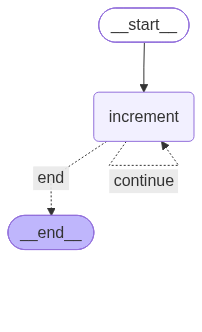

In [19]:
display(Image(count_graph.get_graph().draw_mermaid_png()))

In [20]:
for event in count_graph.stream({"count": 0}):
    print(event)

{'increment': {'count': 1}}
{'increment': {'count': 2}}
{'increment': {'count': 3}}
{'increment': {'count': 4}}
{'increment': {'count': 5}}


핵심 포인트:

- `increment` 노드가 실행될 때마다 State의 `count`가 1씩 증가한다.
- `route_by_count`는 State를 변경하지 않고 다음 경로만 결정한다.
- `"continue": "increment"` 연결을 통해 이전 노드로 돌아갈 수 있다.
- `count`가 5 이상이면 `END`로 이동해 반복을 종료한다.

### 언제 Node를 나눌까?

LangGraph에서는 보통 다음 기준으로 Node를 나눈다.

- **책임이 분리되는가?** 서로 다른 역할을 수행하는 작업은 별도의 Node로 나눈다.
- **상태가 의미 있게 바뀌는가?** 중간 결과를 State에 저장하고 다음 단계에서 사용해야 한다면 Node를 나누는 것이 좋다.
- **분기나 재시도가 필요한가?** 결과에 따라 경로가 달라지거나 특정 작업만 다시 실행해야 한다면 독립된 Node로 구성한다.
- **관찰이 필요한가?** 실행 결과, 소요 시간, 오류 등을 단계별로 확인해야 하는 작업은 별도의 Node로 나눈다.

앞의 조건부 분기 예제는 언어 감지와 답변 생성을, 반복 예제는 숫자 추측과 결과 확인을 각각 별도의 Node로 나누었다. 반대로 항상 함께 실행되고 개별적인 분기, 재시도, 관찰이 필요 없는 작은 작업은 하나의 Node 안에서 처리해도 된다.


### Reducer

노드가 반환한 값은 기본적으로 기존 State 값을 덮어쓴다. State 필드에 **Reducer**를 지정하면 기존 값과 새 값을 어떻게 합칠지 정의할 수 있다.

`Annotated`는 Python에서 타입에 부가 정보를 붙이는 문법이다. `Annotated[기본 타입, 메타데이터]` 형식으로 사용하며, 기본 타입은 그대로 유지된다.

LangGraph는 이 메타데이터 위치의 함수를 Reducer로 사용한다. 따라서 `Annotated[list, add_messages]`는 값의 타입이 `list`이고, State를 업데이트할 때 `add_messages`로 기존 값과 새 값을 합친다는 뜻이다.

```python
name: str                              # reducer 없음 → 새 값으로 덮어쓰기
messages: Annotated[list, add_messages] # 대화 메시지 누적
logs: Annotated[list, operator.add]     # 기존 리스트와 새 리스트 연결
```

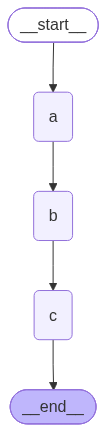

name: C가 덮어씀
logs: ['A 실행', 'B 실행', 'C 실행']
messages:
  human: 안녕
  ai: 반가워!
  human: 잘 가!


In [21]:
class ReducerDemo(TypedDict):
    name: str                                    # reducer 없음 → 덮어쓰기
    messages: Annotated[list, add_messages]       # add_messages → 대화 메시지 누적
    logs: Annotated[list, operator.add]           # operator.add → 리스트 이어붙이기


def step_a(state: ReducerDemo):
    return {
        "name": "A가 설정",
        "messages": [HumanMessage(content="안녕")],
        "logs": ["A 실행"],
    }


def step_b(state: ReducerDemo):
    return {
        "name": "B가 덮어씀",
        "messages": [AIMessage(content="반가워!")],
        "logs": ["B 실행"],
    }


def step_c(state: ReducerDemo):
    return {
        "name": "C가 덮어씀",
        "messages": [HumanMessage(content="잘 가!")],
        "logs": ["C 실행"],
    }


demo_builder = StateGraph(ReducerDemo)
demo_builder.add_node("a", step_a)
demo_builder.add_node("b", step_b)
demo_builder.add_node("c", step_c)
demo_builder.add_edge(START, "a")
demo_builder.add_edge("a", "b")
demo_builder.add_edge("b", "c")
demo_builder.add_edge("c", END)

demo_graph = demo_builder.compile()
display(Image(demo_graph.get_graph().draw_mermaid_png()))

result = demo_graph.invoke({"messages": [], "logs": []})

print(f"name: {result['name']}")
print(f"logs: {result['logs']}")
print(f"messages:")
for msg in result["messages"]:
    print(f"  {msg.type}: {msg.content}")

reducer 선택 가이드:

| 상황 | reducer | 동작 |
|------|---------|------|
| 최신 값만 필요 (이름, 최종 판정 등) | 없음 | 덮어쓰기 |
| 대화 메시지 누적 | `add_messages` | 메시지 형식으로 처리하며 누적 |
| 로그, 결과 목록 누적 | `operator.add` | 단순 리스트 이어붙이기 (`+`) |

단순히 리스트를 이어 붙이는 경우에는 `operator.add`로도 메시지를 누적할 수 있다. `add_messages`는 여러 입력 형식을 메시지 객체로 변환해 처리하는 메시지 전용 Reducer이므로 대화 기록에는 주로 `add_messages`를 사용한다.

State 스키마를 잘 설계하면 이후 모든 노드가 깔끔해진다. 이 부분은 앞으로 계속 반복된다.

## Chain vs LangGraph

| | Chain | LangGraph |
|---|---|---|
| 흐름 | 직선 (A → B → C) | 분기 + 루프 가능 |
| 상태 | 이전 단계 출력만 전달 | State로 전체 공유 |
| 제어 | 고정된 순서 | 조건에 따라 동적 결정 |
| 디버깅 | 각 단계 출력 확인 | 그래프 시각화 + 노드별 트레이싱 |
| 적합한 경우 | 단순 파이프라인 | 분기, 반복, 상태 관리가 필요한 경우 |

### 실습 1: 감정 분석 라우터

사용자의 문장을 받아 감정을 분석하고, 긍정이면 긍정 응답, 부정이면 위로 응답을 생성하는 그래프를 만들어보자.

```
START → analyze → 긍정? → respond_positive → END
                   부정? → respond_negative → END
```

**테스트 입력**:
```python
sentiment_graph.invoke({"text": "오늘 승진했어! 너무 기뻐!"})
sentiment_graph.invoke({"text": "프로젝트가 엎어졌어... 힘들다"})
```

In [4]:
class SentimentState(TypedDict):
    text: str
    sentiment: str
    result: str

def analyze(state: SentimentState):
    text = state['text']
    result = llm.invoke(f"다음 문장을 받아 감정을 분석하고 긍정이면 'positive', 부정이면 'negative'로만 출력해 : {text}")
    return {"sentiment": result.text}

def respond_positive(state: SentimentState):
    text = state['text']
    result = llm.invoke(f"다음 문장을 보고 긍정적으로 응답해줘 : {text}")
    return {"result": result.text}

def respond_negative(state: SentimentState):
    text = state['text']
    result = llm.invoke(f"다음 문장을 보고 위로 응답으로 출력해줘 : {text}")
    return {"result": result.text}

def route_by_sentimet(state: SentimentState):
    sentiment = state['sentiment']
    sentiment = sentiment.strip().lower()

    if sentiment == "positive":
        return "positive"
    return "negative"

graph_builder = StateGraph(SentimentState)

graph_builder.add_node("analyze", analyze)
graph_builder.add_node("respond_positive", respond_positive)
graph_builder.add_node("respond_negative", respond_negative)

graph_builder.add_edge(START, "analyze")
graph_builder.add_conditional_edges(
    "analyze",
    route_by_sentimet,
    {
        "positive": "respond_positive",
        "negative": "respond_negative"
    }
)

sentiment_graph = graph_builder.compile()

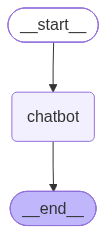

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
for event in sentiment_graph.stream({'text' : "오늘 승진했어! 너무 기뻐!"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

# sentiment_graph.invoke({"text": "오늘 승진했어! 너무 기뻐!"})
# sentiment_graph.invoke({"text": "프로젝트가 엎어졌어... 힘들다"})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[analyze] {'sentiment': 'positive'}

[respond_positive] {'result': '**와, 정말 진심으로 축하드려요! 🥳🎉**\n\n그동안 흘린 땀과 노력이 이렇게 멋진 결실을 맺은 거라 제가 다 뿌듯하고 기쁘네요! 오늘만큼은 그동안의 수고를 다 털어버리고, 세상에서 가장 행복하고 특별한 하루를 보내시길 바라요. 맛있는 것도 꼭 챙겨 드시고요!\n\n새로운 위치에서 펼쳐질 앞날을 응원합니다. 승진을 다시 한번 축하드려요! 👏✨'}



### 실습 2: 숫자 맞히기

LLM이 1~100 사이의 숫자를 추측하고, 정답이 아니면 범위를 좁혀 다시 시도하는 그래프를 만들어보자.

```
START → guess → check → 정답? → END
                  ↑      오답? → guess로 돌아감
```

`check` 노드는 추측값이 정답보다 작으면 `low`를 높이고, 크면 `high`를 낮춘다. 예를 들어 정답이 37일 때 50을 추측하면 다음 추측 범위는 1~49가 된다.

**테스트 입력**:
```python
guess_graph.stream({"target": 37})
```

In [28]:
class GuessState(TypedDict):
    guess : int
    low : int
    high : int
    target : int

def guess(state: GuessState):
    low = state.get('low', 1)
    high = state.get('high', 100)

    result = llm.invoke(f"{low}부터 {high}사이의 정수인 숫자를 추축해서 정수(소수점이 없는) 1개 출력해, 숫자만 출력해")
    return {"guess": int(result.text)}

def check(state: GuessState):
    guess = state['guess']
    target = state['target']

    if guess > target:
        return {"high" : guess -1}
    elif guess < target:
        return {"low" : guess +1}
    else:
        print("성공")
        return {}

def router_success(state: GuessState):
    guess = state['guess']
    target = state['target']

    if guess == target:
        return "end"
    return "retry"

graph_builder = StateGraph(GuessState)

graph_builder.add_node("guess", guess)
graph_builder.add_node("check", check)

graph_builder.add_edge(START, "guess")
graph_builder.add_edge("guess", "check")
graph_builder.add_conditional_edges(
    "check",
    router_success,
    {
        "end": END,
        "retry": "guess"
    }
)

guess_graph = graph_builder.compile()

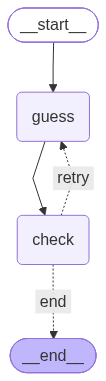

In [23]:
display(Image(guess_graph.get_graph().draw_mermaid_png()))

In [29]:
for event in guess_graph.stream({'target' : 37}):
    for node_name, value in event.items():
        if value:
            print(f"[{node_name}] {value}")
            print()

[guess] {'guess': 42}

[check] {'high': 41}

[guess] {'guess': 27}

[check] {'low': 28}

[guess] {'guess': 35}

[check] {'low': 36}

[guess] {'guess': 38}

[check] {'high': 37}

[guess] {'guess': 36}

[check] {'low': 37}

[guess] {'guess': 37}

성공


### 실습 3: 글 작성 → 검토 → 재작성

주제를 받아 짧은 글을 작성하고, 검토 후 품질이 부족하면 피드백을 반영해 다시 작성하는 그래프를 만들어보자.

```
START → write → review → 통과? → END
                         미흡? → write로 돌아감
```

**테스트 입력**:
```python
writing_graph.stream({"topic": "AI가 교육에 미치는 영향"})
```

In [34]:
from typing import Literal
from pydantic import BaseModel

class WritingState(TypedDict):
    topic : str
    result : Literal['pass', 'fail']
    sentense : str
    feedback : str

class ReviewResult(BaseModel):
    result : Literal['pass', 'fail']
    feedback : str

llm_review_result = llm.with_structured_output(ReviewResult)

def writing(state: WritingState):
    topic = state['topic']

    sentense = llm.invoke(f"{topic}을 주제를 받아서 짧은 글 작성해줘")
    return {"sentense": sentense.text}

def review(state: WritingState):
    topic = state['topic']
    sentense = state['sentense']

    result = llm_review_result.invoke(f"""
    {sentense}는 {topic}에 대한 글이야. 이 글을 보고 검토 해줘
    - result에는 'pass' 또는 'fail'를 담아주고
    - feedback에는 그렇게 생각한 이유를 담아줘
    """)
    return {"result":result.result, "feedback":result.feedback}

def router_by_result(state: WritingState):
    result = state['result']

    if result == 'pass':
        return 'pass'
    return 'fail'

graph_builder = StateGraph(WritingState)

graph_builder.add_node("writing", writing)
graph_builder.add_node("review", review)

graph_builder.add_edge(START, "writing")
graph_builder.add_edge("writing", "review")
graph_builder.add_conditional_edges(
    "review",
    router_by_result,
    {
        "pass": END,
        "fail": "writing"
    }
)

writing_graph = graph_builder.compile()

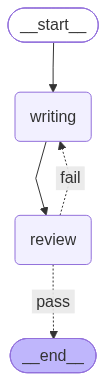

In [32]:
display(Image(writing_graph.get_graph().draw_mermaid_png()))

In [35]:
for event in writing_graph.stream({"topic": "AI가 교육에 미치는 영향"}):
    for node_name, value in event.items():
        print(f"[{node_name}] {value}")
        print()

[writing] {'sentense': '**[AI가 바꾸는 교육의 미래: 맞춤형 학습과 인간적 교감의 조화]**\n\n인공지능(AI) 기술의 급격한 발전은 교육 현장에도 혁명적인 변화를 가져오고 있습니다. 과거의 일방적인 지식 전달 방식에서 벗어나, AI는 교육의 패러다임을 근본적으로 바꾸고 있습니다.\n\n가장 큰 긍정적 변화는 **‘개인 맞춤형 학습’**의 실현입니다. AI는 학생 개개인의 학습 속도, 이해도, 취약점을 실시간으로 분석하여 최적화된 콘텐츠를 제공합니다. 이를 통해 상위권 학생은 깊이 있는 탐구를, 기초가 부족한 학생은 차근차근 보완할 수 있는 기회를 가집니다. 또한, 교사들은 단순 채점이나 행정 업무 부담을 줄이고, 학생들과의 정서적 교감 및 맞춤형 상담에 더 많은 시간을 할애할 수 있게 되었습니다.\n\n하지만 해결해야 할 과제도 명확합니다. AI에 대한 과도한 의존은 학생들의 스스로 생각하는 힘, 즉 비판적 사고력과 창의성을 약화시킬 우려가 있습니다. 더불어 AI 기술에 대한 접근성 차이로 인한 **‘교육 격차’** 문제와 표절, 정보의 신뢰성 등 윤리적 문제도 떠오르고 있습니다.\n\n결국 AI는 교사를 대체하는 것이 아니라, 교육의 가능성을 확장하는 **‘지능형 도구’**로 바라봐야 합니다. AI가 제공하는 기술적 효율성 위에 인간 교사의 따뜻한 공감과 윤리적 지도가 어우러질 때, 미래 교육은 비로소 모든 학생의 잠재력을 꽃피우는 진정한 혁신을 이룰 수 있을 것입니다.'}

[review] {'result': 'pass', 'feedback': 'AI가 교육에 미치는 긍정적 영향과 문제점, 향후 방향성을 균형 있게 다루었으며, 논리적 구조와 결론이 명확하여 교육적 메시지를 효과적으로 전달하고 있습니다.'}

